                               Skin_Diseases_Detection_Using_Deep-Learning(NOTEBOOK)                           

# =============================================================================
# GOOGLE COLAB — Skin Disease Detection (30 Classes, 6400 Images)
# GPU: Tesla T4 or V100 (free/pro version)
#
# OPTIMIZATIONS:
# ✅ EfficientNetB2 (best for 6.4K images)
# ✅ 192×192 resolution (efficient training)
# ✅ Batch size 32 (optimal for 6.4K dataset)
# ✅ Strong augmentation (combat overfitting)
# ✅ Focal loss + class weights (handle imbalance)
# ✅ Two-phase training (head → full fine-tune)
# =============================================================================


In [1]:

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Install required packages
!pip install -q tensorflow>=2.13 seaborn scikit-learn matplotlib

import os
import warnings
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers as L, optimizers, callbacks
from tensorflow.keras.applications import EfficientNetB2
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

warnings.filterwarnings("ignore")
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

print("=" * 60)
print("✅ TensorFlow version  :", tf.__version__)
print("✅ GPU detected        :", tf.config.list_physical_devices("GPU"))
print("=" * 60)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ TensorFlow version  : 2.20.0
✅ GPU detected        : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Configuration & Auto Train/Val/Test Split

## Upload & Extract Dataset

In [2]:
import os
import zipfile

ZIP_PATH = "/content/drive/MyDrive/DATASET/SMALL dayaset/IMG_CLASSES_DATASET.zip"
EXTRACT_DIR = "/content/dataset"

VALID_EXT = (".jpg", ".jpeg", ".png")

# ── Extract only if not already extracted ──
if not os.path.exists(EXTRACT_DIR) or len(os.listdir(EXTRACT_DIR)) == 0:
    os.makedirs(EXTRACT_DIR, exist_ok=True)
    print(f"📦 Extracting {ZIP_PATH} ...")

    with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
        zip_ref.extractall(EXTRACT_DIR)

    print("✅ Extraction complete!")
else:
    print("✅ Dataset already extracted, skipping...")

# ── Locate dataset root (strict) ──
SOURCE_DIR = os.path.join(EXTRACT_DIR, "IMG_CLASSES_DATASET")

if not os.path.exists(SOURCE_DIR):
    raise Exception("❌ IMG_CLASSES_DATASET folder not found!")

print(f"\n📂 Dataset path: {SOURCE_DIR}")

# ── Class distribution (filtered) ──
classes = [d for d in os.listdir(SOURCE_DIR)
           if os.path.isdir(os.path.join(SOURCE_DIR, d))]

print(f"📊 Total classes: {len(classes)}")

for cls in sorted(classes):
    cls_path = os.path.join(SOURCE_DIR, cls)
    images = [f for f in os.listdir(cls_path) if f.lower().endswith(VALID_EXT)]
    print(f"   • {cls:<40} {len(images):>4} images")

✅ Dataset already extracted, skipping...

📂 Dataset path: /content/dataset/IMG_CLASSES_DATASET
📊 Total classes: 30
   • 1. Eczema                                 200 images
   • 11. Pigment                               200 images
   • 13. Akne                                  200 images
   • 15. Actinic Keratosis Basal Cell Carcinoma and other Malignant Lesions  200 images
   • 16. Bullous Disease Photos                200 images
   • 17. Cellulitis Impetigo and other Bacterial Infections  200 images
   • 18. Exanthems and Drug Eruptions          200 images
   • 19. Hair Loss Photos Alopecia and other Hair Diseases  200 images
   • 2. Melanoma                               200 images
   • 20. Herpes HPV and other STDs Photos      200 images
   • 21. Light Diseases and Disorders of Pigmentation  200 images
   • 22. Lupus and other Connective Tissue diseases  200 images
   • 23. Nail Fungus and other Nail Disease    200 images
   • 24. Poison Ivy Photos and other Contact Dermatitis  200

## Merge Duplicate

In [3]:
import os
import shutil

SOURCE_DIR = "/content/dataset/IMG_CLASSES_DATASET"

merge_map = {
    "Warts Molluscum and other Viral Infections": [
        "10. Warts Molluscum and other Viral Infections",
        "33. Warts Molluscum and other Viral Infections"
    ],
    "Seborrheic Keratoses and other Benign Tumors": [
        "27. Seborrheic Keratoses and other Benign Tumors",
        "8. Seborrheic Keratoses and other Benign Tumors"
    ],
    "Tinea Ringworm Candidiasis and other Fungal Infections": [
        "29. Tinea Ringworm Candidiasis and other Fungal Infections",
        "9. Tinea Ringworm Candidiasis and other Fungal Infections"
    ],
    "Enfeksiyonel": [
        "12. Enfeksiyonel",
        "14. Enfeksiyonel"
    ]
}

for new_class, old_classes in merge_map.items():
    new_path = os.path.join(SOURCE_DIR, new_class)
    os.makedirs(new_path, exist_ok=True)

    for old in old_classes:
        old_path = os.path.join(SOURCE_DIR, old)

        if os.path.exists(old_path):
            for file in os.listdir(old_path):
                shutil.move(
                    os.path.join(old_path, file),
                    os.path.join(new_path, file)
                )
            shutil.rmtree(old_path)

print("✅ Duplicate classes merged")

✅ Duplicate classes merged


In [4]:
classes = [d for d in os.listdir(SOURCE_DIR) if os.path.isdir(os.path.join(SOURCE_DIR, d))]
print("Total classes after merge:", len(classes))

Total classes after merge: 30


## Configuration & Auto Train/Val/Test Split


In [5]:
import os, shutil, random
import numpy as np
import tensorflow as tf

# ── Paths ──
DATASET_PATH = "/content/dataset/IMG_CLASSES_DATASET"   # ← FIXED
WORK_DIR     = "/content/split_data"

TRAIN_DIR = os.path.join(WORK_DIR, "train")
VAL_DIR   = os.path.join(WORK_DIR, "val")
TEST_DIR  = os.path.join(WORK_DIR, "test")

# ── Config ──
SEED = 42
IMG_SIZE = (300, 300)
BATCH_SIZE = 16

TRAIN_SPLIT = 0.70
VAL_SPLIT   = 0.15

VALID_EXT = (".jpg", ".jpeg", ".png")

# ── Reproducibility ──
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ── Remove old split ──
shutil.rmtree(WORK_DIR, ignore_errors=True)

# ── Split function ──
def split_dataset():
    classes = sorted(os.listdir(DATASET_PATH))
    print(f"Found {len(classes)} classes")

    for cls in classes:
        cls_path = os.path.join(DATASET_PATH, cls)
        if not os.path.isdir(cls_path):
            continue

        images = [f for f in os.listdir(cls_path) if f.lower().endswith(VALID_EXT)]

        if len(images) == 0:
            print(f"⚠️ Skipping empty class: {cls}")
            continue

        random.shuffle(images)

        n = len(images)
        n_train = int(n * TRAIN_SPLIT)
        n_val   = int(n * VAL_SPLIT)

        splits = {
            TRAIN_DIR: images[:n_train],
            VAL_DIR  : images[n_train:n_train+n_val],
            TEST_DIR : images[n_train+n_val:]
        }

        for dest_root, files in splits.items():
            dest = os.path.join(dest_root, cls)
            os.makedirs(dest, exist_ok=True)

            for f in files:
                src_file = os.path.join(cls_path, f)
                dst_file = os.path.join(dest, f)

                try:
                    os.link(src_file, dst_file)   # ← FAST (preferred)
                except:
                    shutil.copy2(src_file, dst_file)  # fallback

    print("✅ Split complete")

split_dataset()

Found 30 classes
✅ Split complete


In [6]:
import numpy as np
import tensorflow as tf

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

## Data Pipeline with Strong Augmentation

In [7]:
AUTOTUNE = tf.data.AUTOTUNE

# ── Balanced augmentation ──
train_augmentation = tf.keras.Sequential([
    L.RandomFlip("horizontal"),
    L.RandomRotation(0.2),
    L.RandomZoom(0.15),
    L.RandomTranslation(0.1, 0.1),
    L.RandomContrast(0.2),
], name="augmentation")

# ── Load raw datasets (to get class names) ──
raw_train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED,
    label_mode="categorical",
)

CLASS_NAMES = raw_train_ds.class_names
NUM_CLASSES = len(CLASS_NAMES)

# ── Build train dataset ──
train_ds = raw_train_ds.map(
    lambda x, y: (tf.cast(x, tf.float32), y),
    num_parallel_calls=AUTOTUNE
)

train_ds = train_ds.map(
    lambda x, y: (train_augmentation(x, training=True), y),
    num_parallel_calls=AUTOTUNE
)

train_ds = train_ds.cache().shuffle(500).prefetch(AUTOTUNE)

# ── Validation dataset ──
val_ds = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False,
    label_mode="categorical",
)

val_ds = val_ds.map(
    lambda x, y: (tf.cast(x, tf.float32), y),
    num_parallel_calls=AUTOTUNE
).cache().prefetch(AUTOTUNE)

# ── Test dataset ──
test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False,
    label_mode="categorical",
)

test_ds = test_ds.map(
    lambda x, y: (tf.cast(x, tf.float32), y),
    num_parallel_calls=AUTOTUNE
).prefetch(AUTOTUNE)

# ── Info ──
print(f"✅ Total classes       : {NUM_CLASSES}")
print(f"✅ Train batches       : {len(train_ds)}")
print(f"✅ Val batches         : {len(val_ds)}")
print(f"✅ Test batches        : {len(test_ds)}")

for images, labels in train_ds.take(1):
    print(f"✅ Image batch shape   : {images.shape}")
    print(f"✅ Label batch shape   : {labels.shape}")

Found 4830 files belonging to 30 classes.
Found 1035 files belonging to 30 classes.
Found 1035 files belonging to 30 classes.
✅ Total classes       : 30
✅ Train batches       : 302
✅ Val batches         : 65
✅ Test batches        : 65
✅ Image batch shape   : (16, 300, 300, 3)
✅ Label batch shape   : (16, 30)


## Class Weights (Handle Imbalance)

In [8]:
def compute_class_weights(train_dir, class_names):
    VALID_EXT = (".jpg", ".jpeg", ".png")

    counts = []

    for cls in class_names:   # ← use same order as dataset
        cls_path = os.path.join(train_dir, cls)

        images = [f for f in os.listdir(cls_path)
                  if f.lower().endswith(VALID_EXT)]

        counts.append(len(images))

    counts = np.array(counts, dtype=np.int64)

    total = counts.sum()

    weights = {
        i: total / (len(class_names) * max(c, 1))
        for i, c in enumerate(counts)
    }

    return weights, counts

CLASS_WEIGHTS, CLASS_COUNTS = compute_class_weights(TRAIN_DIR, CLASS_NAMES)

print("=" * 65)
print(f"{'Class':<40} {'Count':>8}  {'Weight':>8}")
print("=" * 65)

for i, (name, count) in enumerate(zip(CLASS_NAMES, CLASS_COUNTS)):
    print(f"{name:<40} {count:>8}  {CLASS_WEIGHTS[i]:>8.3f}")

print("=" * 65)
print(f"Min weight: {min(CLASS_WEIGHTS.values()):.3f}")
print(f"Max weight: {max(CLASS_WEIGHTS.values()):.3f}")
print(f"Total train images: {CLASS_COUNTS.sum()}")

Class                                       Count    Weight
1. Eczema                                     140     1.150
11. Pigment                                   140     1.150
13. Akne                                      140     1.150
15. Actinic Keratosis Basal Cell Carcinoma and other Malignant Lesions      140     1.150
16. Bullous Disease Photos                    140     1.150
17. Cellulitis Impetigo and other Bacterial Infections      140     1.150
18. Exanthems and Drug Eruptions              140     1.150
19. Hair Loss Photos Alopecia and other Hair Diseases      140     1.150
2. Melanoma                                   140     1.150
20. Herpes HPV and other STDs Photos          140     1.150
21. Light Diseases and Disorders of Pigmentation      140     1.150
22. Lupus and other Connective Tissue diseases      140     1.150
23. Nail Fungus and other Nail Disease        140     1.150
24. Poison Ivy Photos and other Contact Dermatitis      140     1.150
25. Rosacea Photos 

## Focal Loss


In [9]:
def focal_loss(gamma=2.0, label_smoothing=0.1):
    def loss_fn(y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)
        y_pred = tf.cast(y_pred, tf.float32)

        # Label smoothing (reduced)
        n = tf.cast(tf.shape(y_true)[-1], tf.float32)
        y_t = y_true * (1.0 - label_smoothing) + (label_smoothing / n)

        # Clip predictions
        y_p = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)

        # Cross entropy
        ce = -tf.reduce_sum(y_t * tf.math.log(y_p), axis=-1)

        # Focal modulation
        p_t = tf.reduce_sum(y_t * y_p, axis=-1)
        focal_weight = tf.pow(1.0 - p_t, gamma)

        return tf.reduce_mean(focal_weight * ce)

    return loss_fn

print("✅ Focal loss defined")
print("   gamma           : 2.0")
print("   label_smoothing : 0.1")

✅ Focal loss defined
   gamma           : 2.0
   label_smoothing : 0.1


##  Build EfficientNetB3



In [10]:
# ── Define missing hyperparameter ──
DROPOUT = 0.5

def build_model(num_classes, dropout):
    base = tf.keras.applications.EfficientNetB3(
        include_top=False,
        weights="imagenet",
        input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3),
    )

    base.trainable = False

    inp = tf.keras.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3))

    x = tf.keras.applications.efficientnet.preprocess_input(inp)
    x = base(x, training=False)

    x = L.GlobalAveragePooling2D()(x)
    x = L.BatchNormalization()(x)
    x = L.Dropout(dropout)(x)

    x = L.Dense(
        256,
        activation="relu",
        kernel_regularizer=tf.keras.regularizers.l2(1e-4)
    )(x)

    x = L.BatchNormalization()(x)
    x = L.Dropout(dropout * 0.5)(x)

    out = L.Dense(
        num_classes,
        activation="softmax",
        dtype="float32",
        name="predictions"
    )(x)

    return tf.keras.Model(inp, out)


print("🔨 Building model...")
model = build_model(NUM_CLASSES, DROPOUT)

model.compile(
    optimizer=optimizers.Adam(learning_rate=3e-4),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=[
        "accuracy",
        tf.keras.metrics.TopKCategoricalAccuracy(k=3, name="top3_acc"),
    ],
)

print("\n📊 Model Summary:")
model.summary()

total_params = model.count_params()
trainable_params = sum(np.prod(v.shape) for v in model.trainable_variables)

print(f"\n✅ Total params     : {total_params:,}")
print(f"✅ Trainable params : {trainable_params:,}  (head only)")

🔨 Building model...

📊 Model Summary:


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 300, 300, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb3 (Functional)     │ (None, 10, 10, 1536)   │    10,783,535 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1536)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1536)           │         6,144 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1536)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       393,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 30)             │         7,710 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,191,885 (42.69 MB)

 Trainable params: 404,766 (1.54 MB)

 Non-trainable params: 10,787,119 (41.15 MB)


✅ Total params     : 11,191,885
✅ Trainable params : 404,766  (head only)


## Callbacks


In [11]:
# ── Define missing hyperparameter ──
MIN_LR = 1e-6

# ── Ensure OUTPUT_DIR exists ──
OUTPUT_DIR = "/content/output"
os.makedirs(OUTPUT_DIR, exist_ok=True)

def get_callbacks(phase):
    ckpt_path = os.path.join(OUTPUT_DIR, f"best_phase{phase}.keras")

    return [
        callbacks.ModelCheckpoint(
            filepath=ckpt_path,
            monitor="val_accuracy",
            save_best_only=True,
            verbose=1,
        ),
        callbacks.EarlyStopping(
            monitor="val_accuracy",
            patience=8,
            restore_best_weights=True,
            verbose=1,
        ),
        callbacks.ReduceLROnPlateau(
            monitor="val_accuracy",
            factor=0.3,
            patience=3,
            min_lr=MIN_LR,
            verbose=1,
        ),
        callbacks.CSVLogger(
            os.path.join(OUTPUT_DIR, f"history_phase{phase}.csv")
        ),
    ]

print("✅ Callbacks fixed (MIN_LR added)")

✅ Callbacks fixed (MIN_LR added)


##  Phase 1: Head-Only Training




In [12]:
# ── Phase 1: Head-Only Training (fixed & complete) ──

# Ensure required variables exist
PHASE1_EPOCHS = 15
PHASE1_LR = 3e-4

# Recompile model with correct LR
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=PHASE1_LR),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=[
        "accuracy",
        tf.keras.metrics.TopKCategoricalAccuracy(k=3, name="top3_acc"),
    ],
)

print("=" * 70)
print("PHASE 1 — Head-Only Training (Backbone Frozen)")
print("=" * 70)
print(f"Epochs      : {PHASE1_EPOCHS}")
print(f"LR          : {PHASE1_LR}")
print(f"Strategy    : Train classifier head only")
print("=" * 70)

history1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=PHASE1_EPOCHS,
    callbacks=get_callbacks(phase=1),
    verbose=1,
)

print("\n✅ Phase 1 Complete")
print(f"   Best val accuracy : {max(history1.history['val_accuracy']):.4f}")
print(f"   Best val top-3    : {max(history1.history['val_top3_acc']):.4f}")

PHASE 1 — Head-Only Training (Backbone Frozen)
Epochs      : 15
LR          : 0.0003
Strategy    : Train classifier head only
Epoch 1/15
302/302 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step - accuracy: 0.1081 - loss: 3.9180 - top3_acc: 0.2246
Epoch 1: val_accuracy improved from None to 0.30628, saving model to /content/output/best_phase1.keras

Epoch 1: finished saving model to /content/output/best_phase1.keras
302/302 ━━━━━━━━━━━━━━━━━━━━ 142s 298ms/step - accuracy: 0.1565 - loss: 3.6487 - top3_acc: 0.2944 - val_accuracy: 0.3063 - val_loss: 2.7228 - val_top3_acc: 0.5198 - learning_rate: 3.0000e-04
Epoch 2/15
302/302 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.2620 - loss: 3.0115 - top3_acc: 0.4516
Epoch 2: val_accuracy improved from 0.30628 to 0.35652, saving model to /content/output/best_phase1.keras

Epoch 2: finished saving model to /content/output/best_phase1.keras
302/302 ━━━━━━━━━━━━━━━━━━━━ 27s 90ms/step - accuracy: 0.2716 - loss: 2.9828 - top3_acc: 0.4658 - val_accuracy: 0.3565 - va

## Phase 2: Full Fine-Tuning

In [13]:
# print("=" * 70)
# print("PHASE 2 — Full Fine-Tuning (All Layers Unfrozen)")
# print("=" * 70)

# # ── Get backbone ──
# base_model = model.layers[1]

# # ── Unfreeze backbone correctly ──
# for layer in base_model.layers:
#     if isinstance(layer, L.BatchNormalization):
#         layer.trainable = False
#     else:
#         layer.trainable = True

# # ── Ensure head layers are trainable (ONLY head, no override) ──
# for layer in model.layers:
#     if layer == base_model:
#         continue
#     if not isinstance(layer, L.BatchNormalization):
#         layer.trainable = True

# # ── Hyperparameters ──
# PHASE2_EPOCHS = 30
# PHASE2_LR = 1e-5

# # ── Compile ──
# model.compile(
#     optimizer=optimizers.Adam(learning_rate=PHASE2_LR),
#     loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
#     metrics=[
#         "accuracy",
#         tf.keras.metrics.TopKCategoricalAccuracy(k=3, name="top3_acc"),
#     ],
# )

# trainable_p2 = sum(np.prod(v.shape) for v in model.trainable_variables)

# print(f"Trainable params : {trainable_p2:,}  (FULL NETWORK)")
# print(f"Epochs           : {PHASE2_EPOCHS}")
# print(f"LR               : {PHASE2_LR}")
# print("=" * 70)

# history2 = model.fit(
#     train_ds,
#     validation_data=val_ds,
#     epochs=PHASE2_EPOCHS,
#     callbacks=get_callbacks(phase=2),
#     verbose=1,
# )

# print("\n✅ Phase 2 Complete")
# print(f"   Best val accuracy : {max(history2.history['val_accuracy']):.4f}")
# print(f"   Best val top-3    : {max(history2.history['val_top3_acc']):.4f}")

In [14]:
print("=" * 70)
print("PHASE 2 — Partial Fine-Tuning (Top layers only)")
print("=" * 70)

base_model = model.layers[1]

# Freeze most layers, unfreeze only top part
for layer in base_model.layers[:-80]:
    layer.trainable = False

for layer in base_model.layers[-80:]:
    if isinstance(layer, L.BatchNormalization):
        layer.trainable = False
    else:
        layer.trainable = True

# Keep head trainable
for layer in model.layers:
    if layer != base_model and not isinstance(layer, L.BatchNormalization):
        layer.trainable = True

PHASE2_EPOCHS = 25
PHASE2_LR = 1e-5

model.compile(
    optimizer=optimizers.Adam(learning_rate=PHASE2_LR),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=[
        "accuracy",
        tf.keras.metrics.TopKCategoricalAccuracy(k=3, name="top3_acc"),
    ],
)

print("Trainable layers:", sum(l.trainable for l in base_model.layers))

history2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=PHASE2_EPOCHS,
    callbacks=get_callbacks(phase=2),
    verbose=1,
)

print("\n✅ Phase 2 Complete")
print(f"   Best val accuracy : {max(history2.history['val_accuracy']):.4f}")

PHASE 2 — Partial Fine-Tuning (Top layers only)
Trainable layers: 63
Epoch 1/25
302/302 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step - accuracy: 0.5774 - loss: 1.8688 - top3_acc: 0.8078
Epoch 1: val_accuracy improved from None to 0.44831, saving model to /content/output/best_phase2.keras

Epoch 1: finished saving model to /content/output/best_phase2.keras
302/302 ━━━━━━━━━━━━━━━━━━━━ 136s 283ms/step - accuracy: 0.5745 - loss: 1.8799 - top3_acc: 0.8035 - val_accuracy: 0.4483 - val_loss: 2.3232 - val_top3_acc: 0.6734 - learning_rate: 1.0000e-05
Epoch 2/25
302/302 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - accuracy: 0.6179 - loss: 1.8070 - top3_acc: 0.8327
Epoch 2: val_accuracy did not improve from 0.44831
302/302 ━━━━━━━━━━━━━━━━━━━━ 30s 101ms/step - accuracy: 0.6072 - loss: 1.8212 - top3_acc: 0.8269 - val_accuracy: 0.4425 - val_loss: 2.3237 - val_top3_acc: 0.6705 - learning_rate: 1.0000e-05
Epoch 3/25
302/302 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - accuracy: 0.6002 - loss: 1.8105 - top3_acc: 0.8315
Epoch 3:

## Evaluate on Test Set

In [15]:
from sklearn.metrics import classification_report

print("=" * 70)
print("EVALUATION — Test Set")
print("=" * 70)

best_model = tf.keras.models.load_model(
    os.path.join(OUTPUT_DIR, "best_phase2.keras"),
    custom_objects={"loss_fn": focal_loss()}
)

test_loss, test_acc, test_top3 = best_model.evaluate(test_ds, verbose=1)

print(f"\n✅ Test Results:")
print(f"   Loss        : {test_loss:.4f}")
print(f"   Accuracy    : {test_acc:.4f}  ({test_acc*100:.2f}%)")
print(f"   Top-3 Acc   : {test_top3:.4f}  ({test_top3*100:.2f}%)")

# Collect predictions
y_true, y_pred = [], []
print("\n📊 Collecting predictions...")
for images, labels in test_ds:
    preds = best_model.predict(images, verbose=0)
    y_true.extend(tf.argmax(labels, axis=1).numpy())
    y_pred.extend(tf.argmax(preds, axis=1).numpy())

print("\n" + "=" * 70)
print("PER-CLASS CLASSIFICATION REPORT")
print("=" * 70)
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, digits=4))

EVALUATION — Test Set
65/65 ━━━━━━━━━━━━━━━━━━━━ 30s 214ms/step - accuracy: 0.4396 - loss: 2.3055 - top3_acc: 0.6541

✅ Test Results:
   Loss        : 2.3055
   Accuracy    : 0.4396  (43.96%)
   Top-3 Acc   : 0.6541  (65.41%)

📊 Collecting predictions...

PER-CLASS CLASSIFICATION REPORT
                                                                        precision    recall  f1-score   support

                                                             1. Eczema     0.3846    0.1667    0.2326        30
                                                           11. Pigment     0.6207    0.6000    0.6102        30
                                                              13. Akne     0.9048    0.6333    0.7451        30
15. Actinic Keratosis Basal Cell Carcinoma and other Malignant Lesions     0.3448    0.3333    0.3390        30
                                            16. Bullous Disease Photos     0.3889    0.2333    0.2917        30
                17. Cellulitis Impetigo

## Training Curves


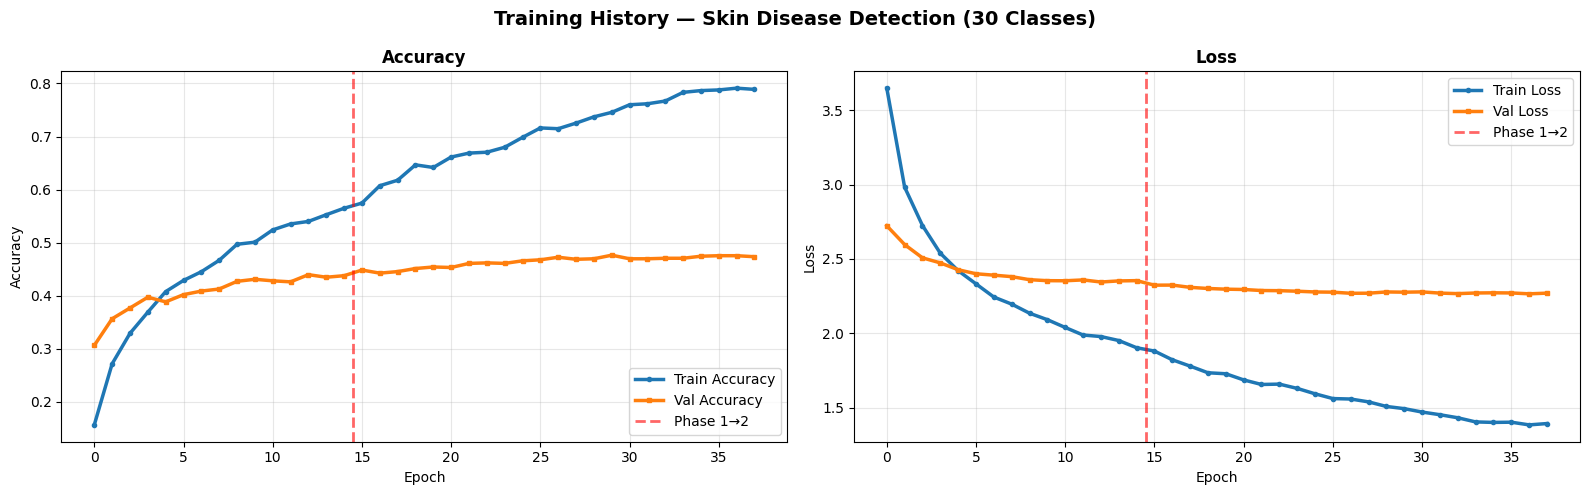

✅ Saved → training_curves.png


In [16]:
# Merge histories
H = {}
for key in history1.history:
    H[key] = history1.history[key] + history2.history.get(key, [])

phase1_epochs = len(history1.history["accuracy"])

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("Training History — Skin Disease Detection (30 Classes)",
             fontsize=14, fontweight="bold")

# Accuracy
axes[0].plot(H["accuracy"], label="Train Accuracy", linewidth=2.5, marker="o", markersize=3)
axes[0].plot(H["val_accuracy"], label="Val Accuracy", linewidth=2.5, marker="s", markersize=3)
axes[0].axvline(phase1_epochs - 0.5, color="red", linestyle="--", linewidth=2, alpha=0.6,
               label="Phase 1→2")
axes[0].set_title("Accuracy", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend(loc="lower right")
axes[0].grid(alpha=0.3)

# Loss
axes[1].plot(H["loss"], label="Train Loss", linewidth=2.5, marker="o", markersize=3)
axes[1].plot(H["val_loss"], label="Val Loss", linewidth=2.5, marker="s", markersize=3)
axes[1].axvline(phase1_epochs - 0.5, color="red", linestyle="--", linewidth=2, alpha=0.6,
               label="Phase 1→2")
axes[1].set_title("Loss", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend(loc="upper right")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "training_curves.png"), dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved → training_curves.png")

##  Confusion Matrix

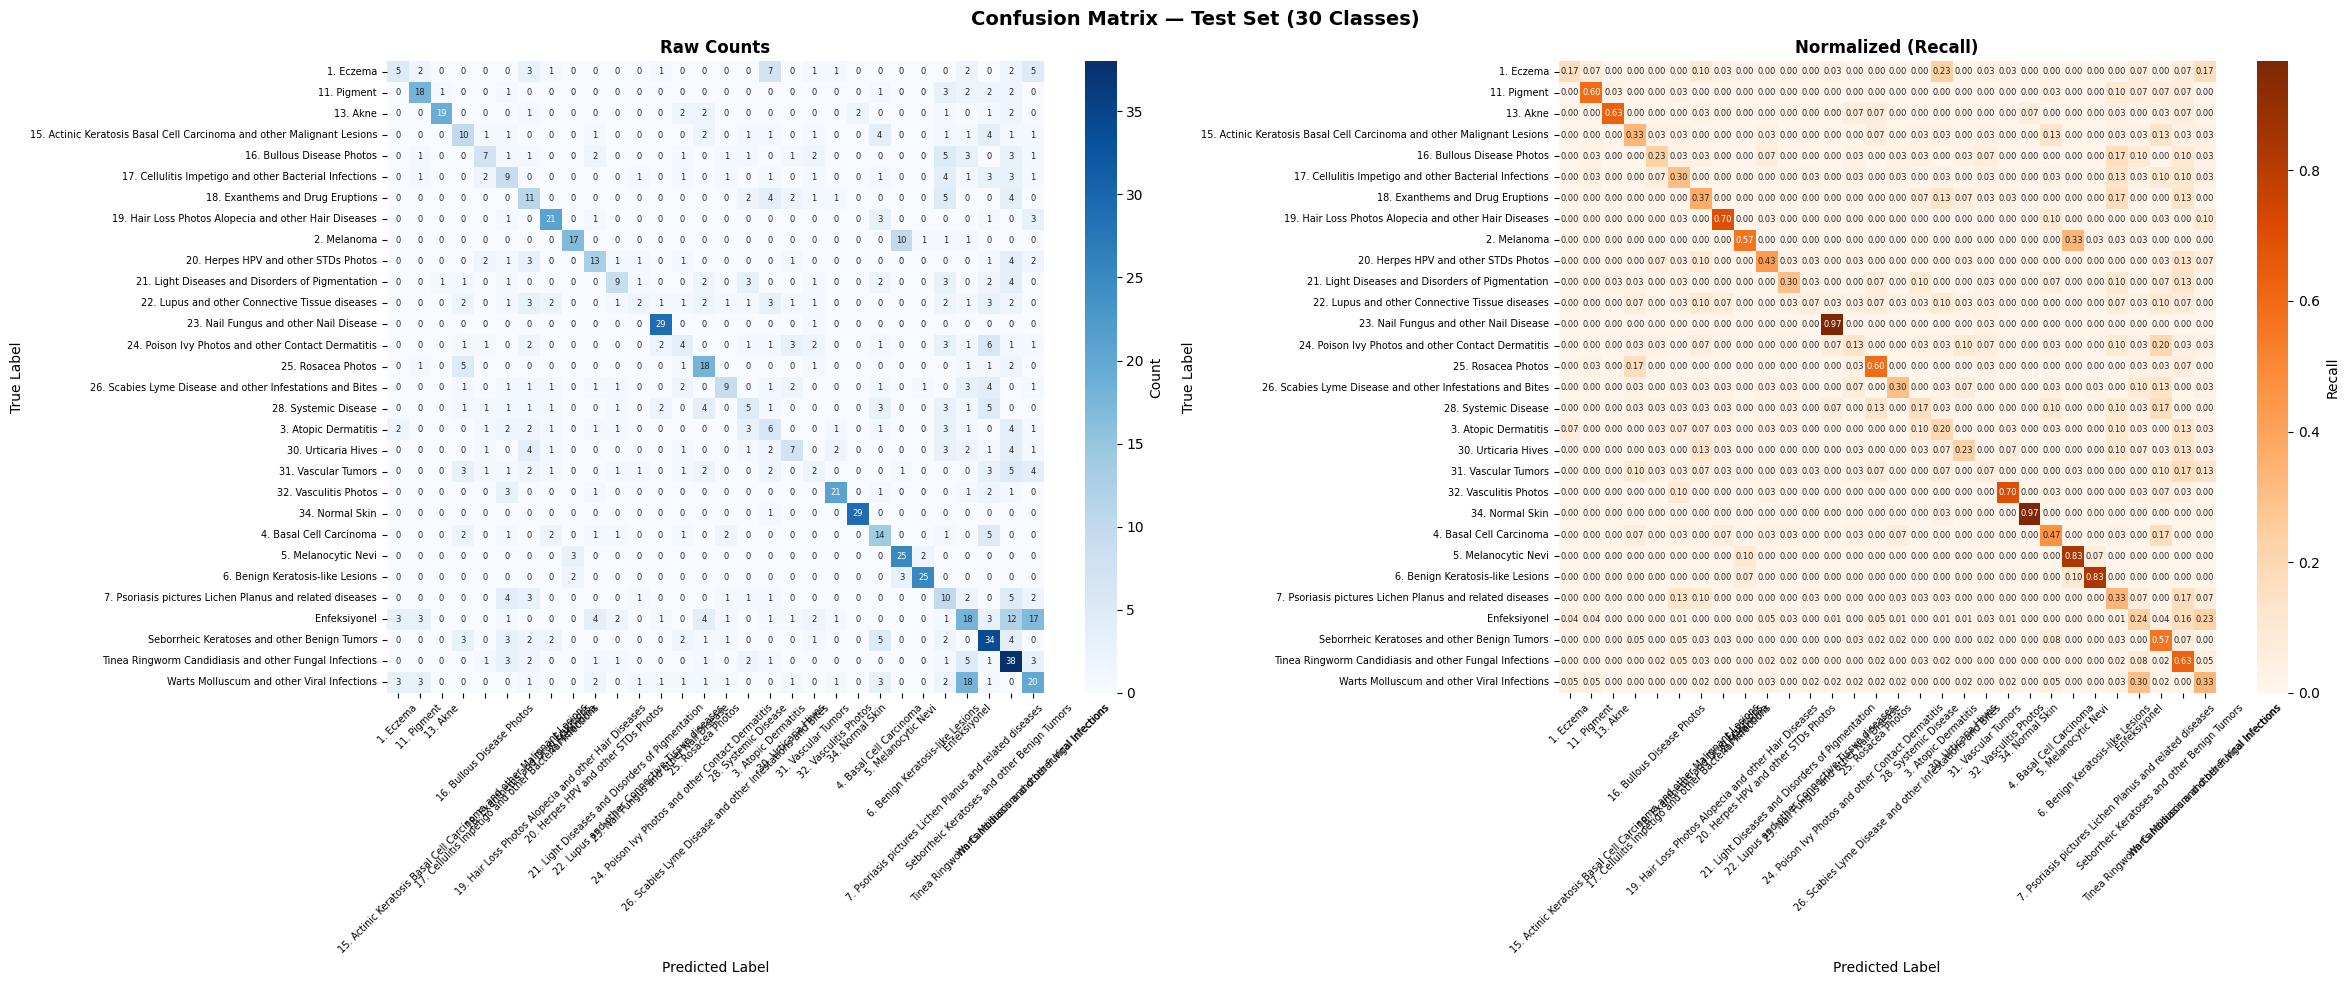

✅ Saved → confusion_matrix.png


In [17]:
cm = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype("float") / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(24, 10))
fig.suptitle("Confusion Matrix — Test Set (30 Classes)", fontsize=14, fontweight="bold")

# Raw counts
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[0],
           xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
           annot_kws={"size": 6}, cbar_kws={"label": "Count"})
axes[0].set_title("Raw Counts", fontsize=12, fontweight="bold")
axes[0].set_ylabel("True Label", fontsize=10)
axes[0].set_xlabel("Predicted Label", fontsize=10)
axes[0].tick_params(axis="x", rotation=45, labelsize=7)
axes[0].tick_params(axis="y", rotation=0, labelsize=7)

# Normalized
sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Oranges", ax=axes[1],
           xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
           annot_kws={"size": 6}, cbar_kws={"label": "Recall"})
axes[1].set_title("Normalized (Recall)", fontsize=12, fontweight="bold")
axes[1].set_ylabel("True Label", fontsize=10)
axes[1].set_xlabel("Predicted Label", fontsize=10)
axes[1].tick_params(axis="x", rotation=45, labelsize=7)
axes[1].tick_params(axis="y", rotation=0, labelsize=7)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "confusion_matrix.png"), dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved → confusion_matrix.png")

## Per-Class Accuracy Save model

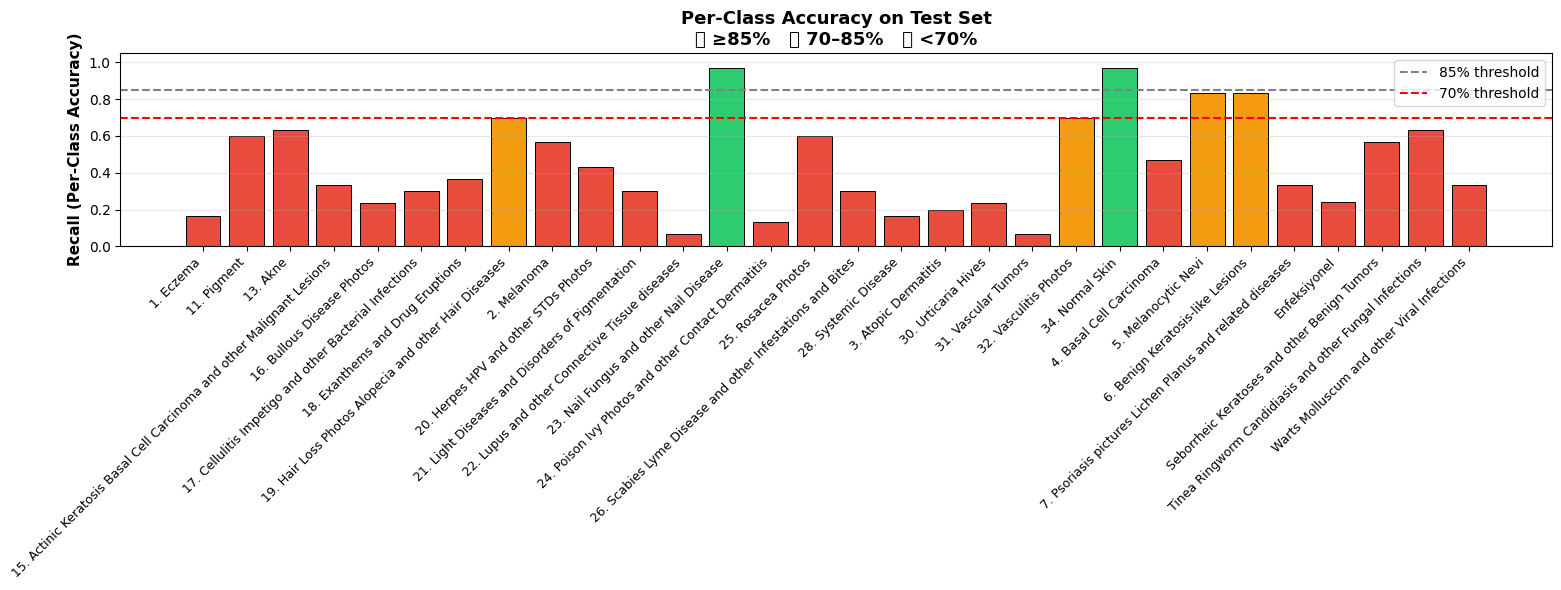


⚠️  Classes below 70% accuracy:
   • 1. Eczema                                     16.7%
   • 11. Pigment                                   60.0%
   • 13. Akne                                      63.3%
   • 15. Actinic Keratosis Basal Cell Carcinoma and other Malignant Lesions 33.3%
   • 16. Bullous Disease Photos                    23.3%
   • 17. Cellulitis Impetigo and other Bacterial Infections 30.0%
   • 18. Exanthems and Drug Eruptions              36.7%
   • 2. Melanoma                                   56.7%
   • 20. Herpes HPV and other STDs Photos          43.3%
   • 21. Light Diseases and Disorders of Pigmentation 30.0%
   • 22. Lupus and other Connective Tissue diseases 6.7%
   • 24. Poison Ivy Photos and other Contact Dermatitis 13.3%
   • 25. Rosacea Photos                            60.0%
   • 26. Scabies Lyme Disease and other Infestations and Bites 30.0%
   • 28. Systemic Disease                          16.7%
   • 3. Atopic Dermatitis                          20.0%
 

In [18]:
# Per-class accuracy
per_class_acc = cm_norm.diagonal()

fig, ax = plt.subplots(figsize=(16, 6))
colors = ["#e74c3c" if a < 0.70 else "#f39c12" if a < 0.85 else "#2ecc71"
         for a in per_class_acc]
ax.bar(range(len(CLASS_NAMES)), per_class_acc, color=colors, edgecolor="black", linewidth=0.7)
ax.axhline(0.85, color="gray", linestyle="--", linewidth=1.5, label="85% threshold")
ax.axhline(0.70, color="red", linestyle="--", linewidth=1.5, label="70% threshold")
ax.set_xticks(range(len(CLASS_NAMES)))
ax.set_xticklabels(CLASS_NAMES, rotation=45, ha="right", fontsize=9)
ax.set_ylabel("Recall (Per-Class Accuracy)", fontsize=11, fontweight="bold")
ax.set_title("Per-Class Accuracy on Test Set\n🟢 ≥85%   🟡 70–85%   🔴 <70%",
            fontsize=13, fontweight="bold")
ax.set_ylim(0, 1.05)
ax.legend(fontsize=10)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "per_class_accuracy.png"), dpi=150, bbox_inches="tight")
plt.show()

# Find weak classes
print("\n⚠️  Classes below 70% accuracy:")
weak = [(CLASS_NAMES[i], f"{v:.1%}") for i, v in enumerate(per_class_acc) if v < 0.70]
if weak:
    for name, acc in weak:
        print(f"   • {name:<45} {acc}")
else:
    print("   ✅ All classes above 70%!")

# ── Save models ──
print("\n💾 Saving models...")

# Keras format
best_model.save(os.path.join(OUTPUT_DIR, "skin_disease_model.keras"))
print(f"✅ Saved → skin_disease_model.keras")

# SavedModel format
best_model.export(os.path.join(OUTPUT_DIR, "saved_model"))
print(f"✅ Saved → saved_model/ (TensorFlow SavedModel)")

# Class names JSON
import json
class_map = {str(i): name for i, name in enumerate(CLASS_NAMES)}
with open(os.path.join(OUTPUT_DIR, "class_names.json"), "w") as f:
    json.dump(class_map, f, indent=2)
print(f"✅ Saved → class_names.json")

## Final Summary & Download

In [19]:
print("\n" + "=" * 75)
print("✅  TRAINING COMPLETE — SKIN DISEASE DETECTION (30 CLASSES)")
print("=" * 75)
print(f"\n📊 DATASET")
print(f"   Training images     : {CLASS_COUNTS.sum() * 0.70:.0f}")
print(f"   Validation images   : {CLASS_COUNTS.sum() * 0.15:.0f}")
print(f"   Test images         : {CLASS_COUNTS.sum() * 0.15:.0f}")
print(f"   Total classes       : {NUM_CLASSES}")

print(f"\n🏗️  ARCHITECTURE")
print(f"   Model               : EfficientNetB2")
print(f"   Input size          : {IMG_SIZE}×{IMG_SIZE}")
print(f"   Batch size          : {BATCH_SIZE}")
print(f"   Total parameters    : {total_params:,}")

print(f"\n📈 RESULTS")
print(f"   Best val accuracy   : {max(H['val_accuracy']):.4f}  ({max(H['val_accuracy'])*100:.2f}%)")
print(f"   Final test accuracy : {test_acc:.4f}  ({test_acc*100:.2f}%)")
print(f"   Final test top-3    : {test_top3:.4f}  ({test_top3*100:.2f}%)")
print(f"   Total epochs        : {len(H['accuracy'])}")

print(f"\n💾 OUTPUT FILES (Saved to Google Drive)")
print(f"   📁 Directory        : {OUTPUT_DIR}")
print(f"   📄 Models           : skin_disease_model.keras, saved_model/")
print(f"   📊 Visualizations   : training_curves.png, confusion_matrix.png, per_class_accuracy.png")
print(f"   📋 Class mapping    : class_names.json")
print(f"   📈 Training history : history_phase1.csv, history_phase2.csv")

print("\n" + "=" * 75)
print("✨ Ready for deployment! Use skin_disease_model.keras for predictions.")
print("=" * 75)

# List all output files
print(f"\n📦 All output files:")
for file in sorted(os.listdir(OUTPUT_DIR)):
    filepath = os.path.join(OUTPUT_DIR, file)
    if os.path.isfile(filepath):
        size = os.path.getsize(filepath) / (1024 * 1024)
        print(f"   ✅ {file:<40} {size:>8.2f} MB")
    else:
        print(f"   📁 {file}/ (directory)")


✅  TRAINING COMPLETE — SKIN DISEASE DETECTION (30 CLASSES)

📊 DATASET
   Training images     : 3381
   Validation images   : 724
   Test images         : 724
   Total classes       : 30

🏗️  ARCHITECTURE
   Model               : EfficientNetB2
   Input size          : (300, 300)×(300, 300)
   Batch size          : 16
   Total parameters    : 11,191,885

📈 RESULTS
   Best val accuracy   : 0.4763  (47.63%)
   Final test accuracy : 0.4396  (43.96%)
   Final test top-3    : 0.6541  (65.41%)
   Total epochs        : 38

💾 OUTPUT FILES (Saved to Google Drive)
   📁 Directory        : /content/output
   📄 Models           : skin_disease_model.keras, saved_model/
   📊 Visualizations   : training_curves.png, confusion_matrix.png, per_class_accuracy.png
   📋 Class mapping    : class_names.json
   📈 Training history : history_phase1.csv, history_phase2.csv

✨ Ready for deployment! Use skin_disease_model.keras for predictions.

📦 All output files:
   ✅ best_phase1.keras                           4